**Corpus Statement**

My corpus is roughly 71 images from my own practice as an illustrator and branding designer — portfolio work, poster designs, and illustrations and paintings sketched over several years. Every image is something I made, not just collected, so I know exactly why each one looks the way it does: the brief, the period of my practice, which choices were deliberate versus habitual. That depth of knowledge means I can immediately tell when a retrieval result matches for the wrong reason — a shared color or composition rather than any real conceptual link — which is what makes this archive a strong testbed for surfacing the machine's mis-seeings. The corpus was consolidated into a single Drive folder without cropping, recaptioning, or filtering. Since every image is my own original work, there are no rights or consent concerns, and the full set is included in the submission.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

CORPUS_FOLDER = '/content/drive/MyDrive/my_archive'
SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')

image_paths = sorted([
    os.path.join(CORPUS_FOLDER, f)
    for f in os.listdir(CORPUS_FOLDER)
    if f.lower().endswith(SUPPORTED_EXTENSIONS)
])

print(f"Found {len(image_paths)} images in: {CORPUS_FOLDER}")
for p in image_paths[:10]:
    print(" ", os.path.basename(p))

Found 72 images in: /content/drive/MyDrive/my_archive
  0-01.png
  0-02.png
  0-03.png
  0-04-04.png
  0-05.png
  0-07-07.png
  01.jpg
  25th-01.png
  IMG_6117.jpg
  IMG_6118.jpg


In [3]:
# transformers must be pinned — newer versions changed SigLIP's output structure
!pip install -q transformers==4.47.0 gradio pillow torch

import sys, torch
print("Python  :", sys.version.split()[0])
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.3 MB/s eta 0:00:00
Python  : 3.12.13
PyTorch : 2.11.0+cu128
CUDA    : True


In [4]:
from transformers import AutoProcessor, AutoModel
import torch

MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(DEVICE)

print(f"SigLIP loaded on {DEVICE.upper()} ✓")
print("Embedding dimension: 768")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

SigLIP loaded on CUDA ✓
Embedding dimension: 768


In [5]:
import numpy as np
from PIL import Image
import torch, os
from transformers import AutoProcessor, AutoModel

MODEL_NAME = "google/siglip-base-patch16-224"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(DEVICE)

SAVE_DIR = CORPUS_FOLDER
all_embeddings = []
valid_paths    = []

print(f"Embedding {len(image_paths)} images on {DEVICE.upper()}...\n")

with torch.no_grad():
    for i, path in enumerate(image_paths):
        try:
            img = Image.open(path).convert("RGB")
            img = Image.fromarray(np.array(img))  # fixes Pillow 12 JPG incompatibility

            inputs = processor(images=img, return_tensors="pt")
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

            # Use vision_model directly — get_image_features() has an output-structure
            # mismatch on this transformers/SigLIP combination.
            vision_outputs = model.vision_model(**inputs)
            embedding = vision_outputs.pooler_output

            embedding = embedding / embedding.norm(dim=-1, keepdim=True)

            all_embeddings.append(embedding.cpu())
            valid_paths.append(path)

            if (i + 1) % 10 == 0 or (i + 1) == len(image_paths):
                print(f"  {i+1}/{len(image_paths)} done")

        except Exception as e:
            print(f"  ⚠ Skipping {os.path.basename(path)}: {e}")

if all_embeddings:
    embeddings_tensor = torch.cat(all_embeddings, dim=0)  # [N, 768]
    print(f"\n✓ Embedded {len(valid_paths)} images")
    print(f"  Shape: {embeddings_tensor.shape}")

    save_path = os.path.join(SAVE_DIR, "embeddings.pt")
    torch.save({"embeddings": embeddings_tensor, "paths": valid_paths}, save_path)
    print(f"✓ Saved → {save_path}")
else:
    print("\n❌ No embeddings generated. Check errors above.")

Embedding 72 images on CUDA...



/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  10/72 done
  20/72 done
  30/72 done
  40/72 done
  50/72 done
  60/72 done
  70/72 done
  72/72 done

✓ Embedded 72 images
  Shape: torch.Size([72, 768])
✓ Saved → /content/drive/MyDrive/my_archive/embeddings.pt


In [6]:
import torch, os

save_path = os.path.join(CORPUS_FOLDER, "embeddings.pt")
data = torch.load(save_path)
embeddings_tensor = data["embeddings"]
valid_paths       = data["paths"]

print(f"✓ Loaded {len(valid_paths)} embeddings")
print(f"  Shape: {embeddings_tensor.shape}")

✓ Loaded 72 embeddings
  Shape: torch.Size([72, 768])


In [7]:
import torch
from PIL import Image
import os


def retrieve(query: str, top_k: int = 5, verbose: bool = False, threshold: float = None):
    if threshold is None:
        threshold = SIMILARITY_THRESHOLD

    inputs = processor(text=[query], return_tensors="pt", padding="max_length")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        text_outputs = model.text_model(**inputs)
        text_emb = text_outputs.pooler_output
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)

        # raw cosine similarity — this is what we rank AND threshold on
        sims = (embeddings_tensor.to(DEVICE) @ text_emb.T).squeeze(-1)

    top_scores, top_idx = torch.topk(sims, k=min(top_k, len(valid_paths)))

    if verbose:
        print(f"Cosine similarities for '{query}': {top_scores.tolist()}")

    results = []
    for score, idx in zip(top_scores.tolist(), top_idx.tolist()):
        if score < threshold:
            continue
        path = valid_paths[idx]
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (224, 224), color="lightgray")
        label = f"{os.path.basename(path)}  (sim: {score:.3f})"
        results.append((img, label))

    return results

# **Gradio Interface**

In [16]:
import gradio as gr
import os
from PIL import Image

SIMILARITY_THRESHOLD = 0.00

def gradio_search(query: str, top_k: int, threshold: float):
    if not query.strip():
        return [], "Enter a query above."

    hits = retrieve(query.strip(), top_k=int(top_k), threshold=threshold)

    if not hits:
        return [], f"No results above threshold {threshold:.2f}. Try lowering it."

    gallery_items = []
    errors = []
    for img, label in hits:
        if img is None:
            errors.append(label)
            continue
        gallery_items.append((img, label))

    status = f"{len(gallery_items)} result(s) shown."
    if errors:
        status += f" ⚠ {len(errors)} image(s) failed to load: {errors}"

    return gallery_items, status

with gr.Blocks(title="Seeing Machines — Level 1 Finder") as demo:
    gr.Markdown("## 🔍 Seeing Machines: Image Archive Search")
    gr.Markdown(
        "Type any description. The system finds images that best match the "
        "*meaning* of your query, not just keywords. Powered by SigLIP.\n\n"
        "Note: SigLIP's raw cosine similarities for this corpus range roughly "
        "from -0.18 to 0.14 (not 0 to 1) — this is expected, not an error."
    )

    with gr.Row(): # Main row for side-by-side layout
        with gr.Column(scale=1): # Column for controls on the left
            with gr.Row(): # Existing row for query and k_slider
                query_box = gr.Textbox(label="Search query", placeholder="e.g. rainy street at night", scale=3)
                k_slider  = gr.Slider(minimum=1, maximum=10, step=1, value=5, label="Top-k results", scale=1)

            threshold_slider = gr.Slider(
                minimum=-0.15,
                maximum=0.7,
                step=0.01,
                value=SIMILARITY_THRESHOLD,
                label="Similarity threshold (higher = stricter match)"
            )

            search_btn = gr.Button("Search", variant="primary")
            status_box = gr.Markdown()

        with gr.Column(scale=2): # Column for gallery on the right
            gallery = gr.Gallery(
                label="Results (filename · similarity score)",
                columns=2, # Changed from 4 to 2 for bigger images
                rows=None, # Let height and columns define row count automatically
                object_fit="contain",
                height=600, # Increased height for more space
                allow_preview=True
            )

    search_btn.click(fn=gradio_search, inputs=[query_box, k_slider, threshold_slider], outputs=[gallery, status_box])
    query_box.submit(fn=gradio_search, inputs=[query_box, k_slider, threshold_slider], outputs=[gallery, status_box])

demo.launch(share=True, debug=True, prevent_thread_lock=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8f563c1c508e5de810.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1368: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8f563c1c508e5de810.gradio.live


### Define Atlas Queries for Threshold Recommendation

These queries are essential for the threshold analysis. This cell defines the `atlas_queries` list, which was missing in the previous execution of the threshold calculation.

In [9]:
atlas_queries = [
    ("A vibrant pink social media advertisement for lipsticks featuring bold, high-contrast modern", "target: social media ad"),
    ("A minimalist flat vector illustration of a lipstick tube against a solid purple background.", "target: minimalist illustration"),
    ("Hand-painted Indian truck art with vibrant colors and ornate, heavy-weighted typography.", "target: truck art"),
    ("Taylor swift eating apple.", "failure: celebrity recognition"),
    ("A blue car", "failure: attribute/color over-indexing"),
    ("Whimsical white cows falling from the sky like rain into a lush green field.", "failure: hallucination/OOD"),
    ("Shah Rukh Khan performing a dance routine on a neon-lit stage.", "failure: celebrity recognition"),
    ("A serene morning at a lush tea garden in Munnar featuring rolling green hills and hand-drawn farmers.", "target: tea garden"),
    ("A 1920s Bauhaus-style poster with rigid geometric shapes and a strict primary color Palette.", "experiment: bauhaus style"),
    ("A surreal dreamscape featuring dozens of watchful blue eyes hidden within a dark, bioluminescent jungle.", "target: surreal dreamscape"),
    ("A logo that uses negative space to hide a second image.", "target: negative space logo"),
    ("A logo that uses negative space to hide a second image.", "target: negative space logo"),
    ("Handwritten typography that feels rushed and imperfect.", "target: handwritten typography")
]

print("✓ atlas_queries defined.")

✓ atlas_queries defined.


### Recalculate Recommended Similarity Threshold

Now that `atlas_queries` is defined, we can re-run the analysis to determine the optimal similarity threshold. This cell replicates the logic from `7z-vhDH1_nwB` to compute and print the recommended value.

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


=== SCORE DISTRIBUTION ACROSS CORPUS ===
Min: -0.181   Max: 0.130   Median: -0.042
  10th percentile: -0.105
  25th percentile: -0.076
  40th percentile: -0.055
  50th percentile: -0.042
  60th percentile: -0.033
  75th percentile: -0.015
  90th percentile: 0.014


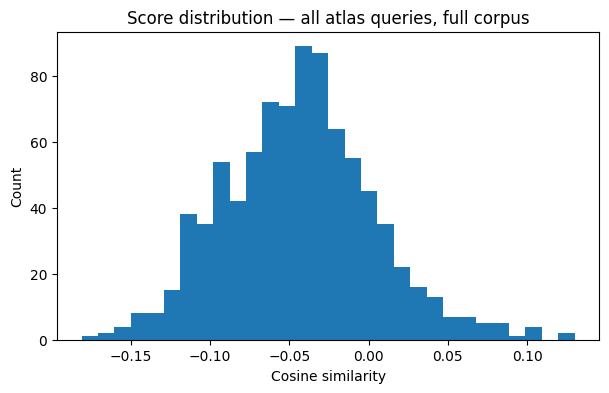


=== RECOMMENDATION ===
Recommended threshold: -0.05
  → target/style-check avg results retained: 46.0
  → failure-query avg results retained: 31.8


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: gather raw cosine similarities across every atlas query, full corpus, no cap ---
raw_scores = {}
for query, category in atlas_queries:
    # Assuming 'retrieve' function is defined and available from previous cells (C65KeYWfx846)
    hits = retrieve(query, top_k=len(valid_paths), threshold=-999)
    scores = [float(label.split("sim: ")[1].rstrip(')')) for _, label in hits]
    raw_scores[query] = (scores, category)

all_scores = np.concatenate([np.array(s) for s, _ in raw_scores.values()])

print("=== SCORE DISTRIBUTION ACROSS CORPUS ===")
print(f"Min: {all_scores.min():.3f}   Max: {all_scores.max():.3f}   Median: {np.median(all_scores):.3f}")
for p in [10, 25, 40, 50, 60, 75, 90]:
    print(f"  {p}th percentile: {np.percentile(all_scores, p):.3f}")

plt.figure(figsize=(7,4))
plt.hist(all_scores, bins=30)
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Score distribution — all atlas queries, full corpus")
plt.show()

# --- Step 2: sweep thresholds, track target vs failure retention ---
# Adjusting the range to match the original cell's potential output or make sense
thresholds_to_test = np.arange(all_scores.min() - 0.01, all_scores.max() + 0.01, 0.01)
target_avgs, failure_avgs = [], []

for t in thresholds_to_test:
    target_counts, failure_counts = [], []
    for query, (scores, category) in raw_scores.items():
        count = sum(1 for s in scores if s >= t)
        if "target" in category or "style check" in category:
            target_counts.append(count)
        elif "failure" in category:
            failure_counts.append(count)
    target_avgs.append(np.mean(target_counts))
    failure_avgs.append(np.mean(failure_counts))

target_avgs = np.array(target_avgs)
failure_avgs = np.array(failure_avgs)
gap = target_avgs - failure_avgs

# --- Step 3: recommend the threshold that maximizes gap, while keeping target recall reasonable ---
min_acceptable_target = target_avgs[0] * 0.6 # Assuming target_avgs[0] is not empty
valid_mask = target_avgs >= min_acceptable_target
if valid_mask.any():
    best_idx = np.argmax(np.where(valid_mask, gap, -np.inf))
else:
    best_idx = np.argmax(gap)

recommended_threshold = round(float(thresholds_to_test[best_idx]), 2)

print(f"\n=== RECOMMENDATION ===")
print(f"Recommended threshold: {recommended_threshold}")
print(f"  → target/style-check avg results retained: {target_avgs[best_idx]:.1f}")
print(f"  → failure-query avg results retained: {failure_avgs[best_idx]:.1f}")


Query: "A vibrant pink social media advertisement for lipsticks featuring bold, high-contrast modern"   [target: social media ad]
→ 4 result(s) above threshold 0.0


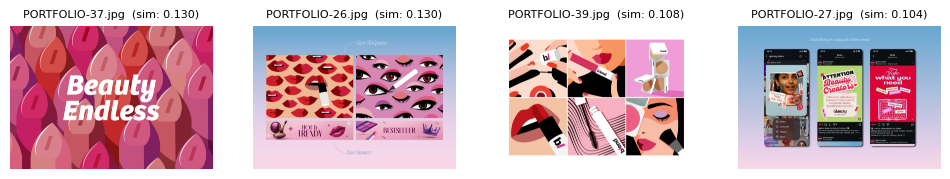


Query: "A minimalist flat vector illustration of a lipstick tube against a solid purple background."   [target: minimalist illustration]
→ 4 result(s) above threshold 0.0


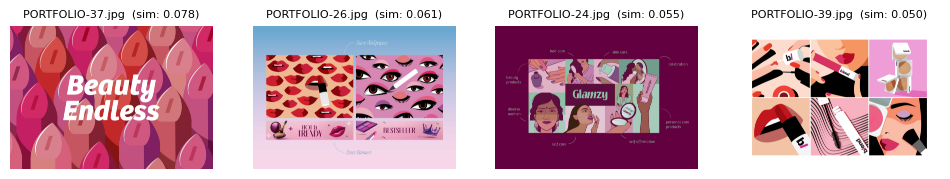

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Query: "Hand-painted Indian truck art with vibrant colors and ornate, heavy-weighted typography."   [target: truck art]
→ 4 result(s) above threshold 0.0


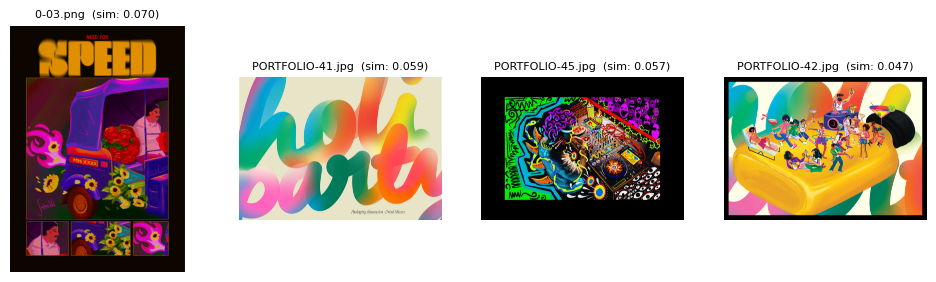


Query: "Taylor swift eating apple."   [failure: celebrity recognition]
→ 2 result(s) above threshold 0.0


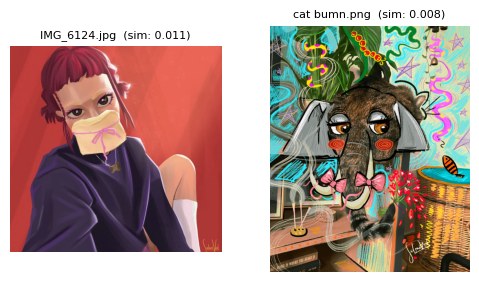


Query: "A blue car"   [failure: attribute/color over-indexing]
→ 3 result(s) above threshold 0.0


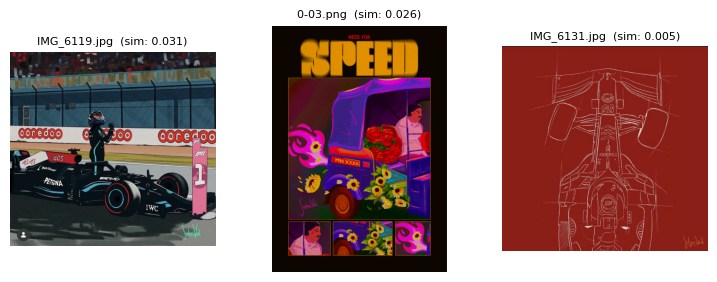


Query: "Whimsical white cows falling from the sky like rain into a lush green field."   [failure: hallucination/OOD]
→ 3 result(s) above threshold 0.0


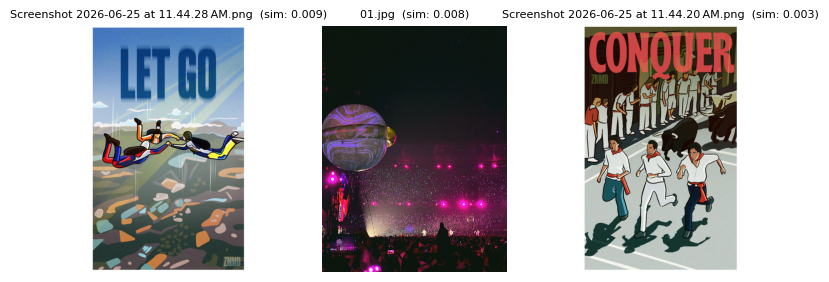


Query: "Shah Rukh Khan performing a dance routine on a neon-lit stage."   [failure: celebrity recognition]
→ 2 result(s) above threshold 0.0


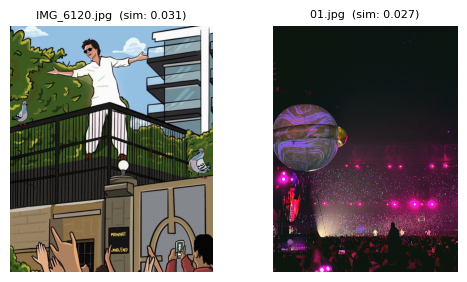


Query: "A serene morning at a lush tea garden in Munnar featuring rolling green hills and hand-drawn farmers."   [target: tea garden]
→ 3 result(s) above threshold 0.0


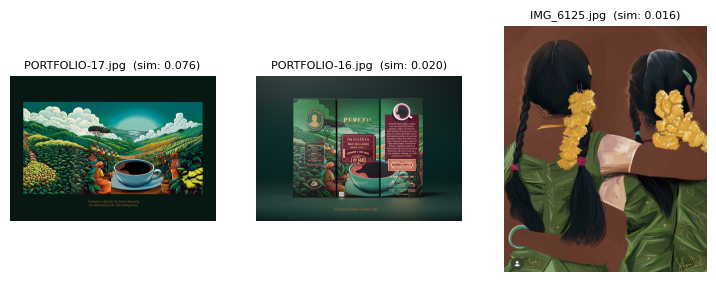


Query: "A 1920s Bauhaus-style poster with rigid geometric shapes and a strict primary color Palette."   [experiment: bauhaus style]
→ 4 result(s) above threshold 0.0


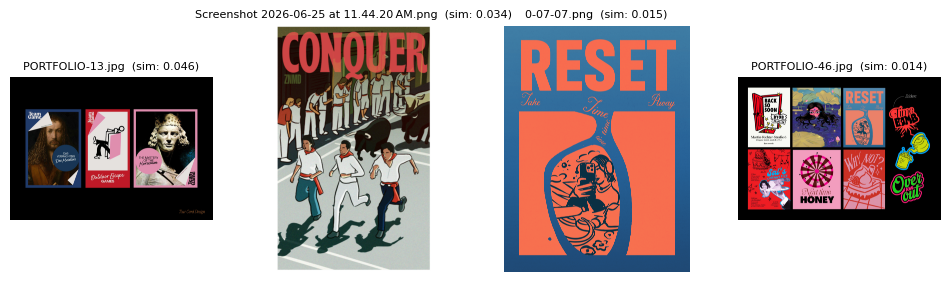


Query: "A surreal dreamscape featuring dozens of watchful blue eyes hidden within a dark, bioluminescent jungle."   [target: surreal dreamscape]
→ 4 result(s) above threshold 0.0


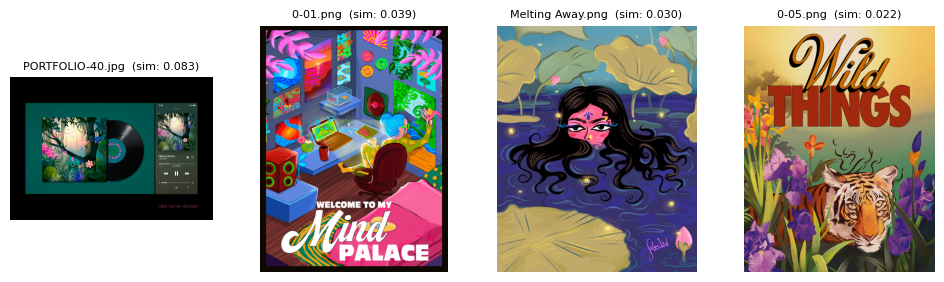


Query: "A logo that uses negative space to hide a second image."   [target: negative space logo]
→ 4 result(s) above threshold 0.0


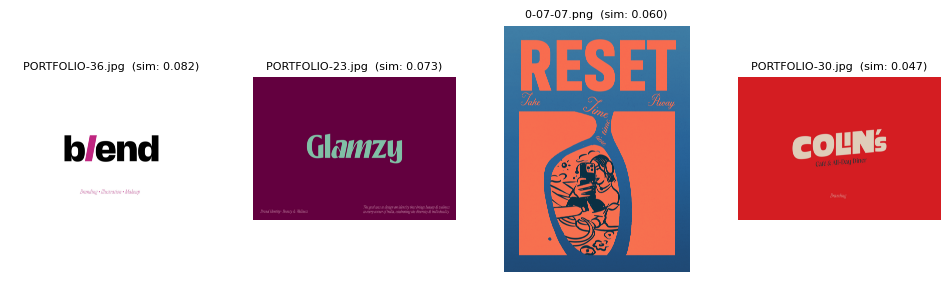


Query: "A logo that uses negative space to hide a second image."   [target: negative space logo]
→ 4 result(s) above threshold 0.0


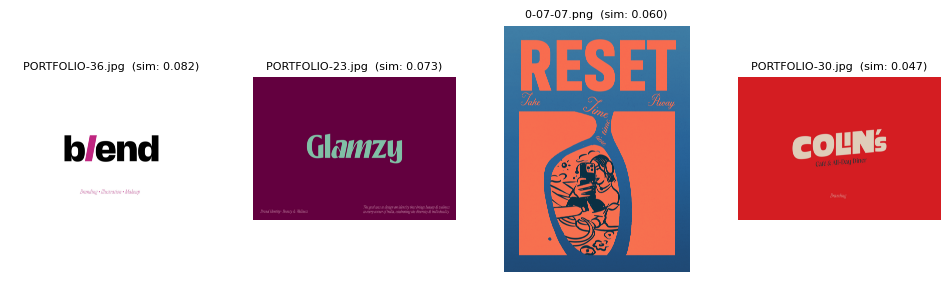


Query: "Handwritten typography that feels rushed and imperfect."   [target: handwritten typography]
→ 4 result(s) above threshold 0.0


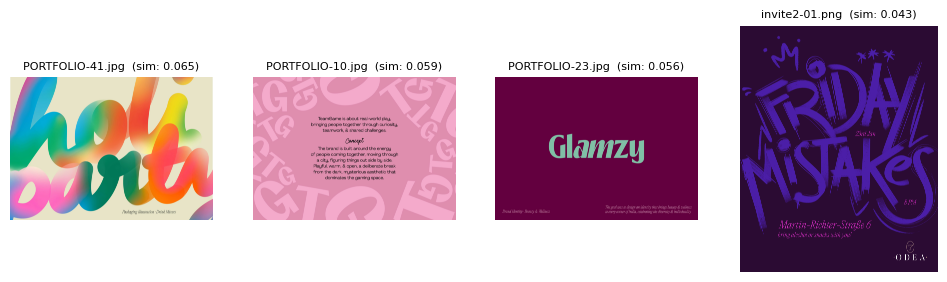


============================== CONCISE QUERY-WISE SUMMARY ==============================

Query: "A vibrant pink social media advertisement for lipsticks featuring bold, high-contrast modern"
  Category: [target: social media ad]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "A minimalist flat vector illustration of a lipstick tube against a solid purple background."
  Category: [target: minimalist illustration]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "Hand-painted Indian truck art with vibrant colors and ornate, heavy-weighted typography."
  Category: [target: truck art]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "Taylor swift eating apple."
  Category: [failure: celebrity recognition]
  Outcome: FAILURE (as expected)
  Analysis: As anticipated, model struggled with celebrity recognition, finding 2

In [11]:
import matplotlib.pyplot as plt

atlas_queries = [
    ("A vibrant pink social media advertisement for lipsticks featuring bold, high-contrast modern", "target: social media ad"),
    ("A minimalist flat vector illustration of a lipstick tube against a solid purple background.", "target: minimalist illustration"),
    ("Hand-painted Indian truck art with vibrant colors and ornate, heavy-weighted typography.", "target: truck art"),
    ("Taylor swift eating apple.", "failure: celebrity recognition"),
    ("A blue car", "failure: attribute/color over-indexing"),
    ("Whimsical white cows falling from the sky like rain into a lush green field.", "failure: hallucination/OOD"),
    ("Shah Rukh Khan performing a dance routine on a neon-lit stage.", "failure: celebrity recognition"),
    ("A serene morning at a lush tea garden in Munnar featuring rolling green hills and hand-drawn farmers.", "target: tea garden"),
    ("A 1920s Bauhaus-style poster with rigid geometric shapes and a strict primary color Palette.", "experiment: bauhaus style"),
    ("A surreal dreamscape featuring dozens of watchful blue eyes hidden within a dark, bioluminescent jungle.", "target: surreal dreamscape"),
    ("A logo that uses negative space to hide a second image.", "target: negative space logo"),
    ("A logo that uses negative space to hide a second image.", "target: negative space logo"),
    ("Handwritten typography that feels rushed and imperfect.", "target: handwritten typography")
]

atlas_results = {}
summary_stats = {"success": [], "failure": [], "no_results": []}

for query, category in atlas_queries:
    hits = retrieve(query, top_k=4)
    atlas_results[query] = hits

    print(f"\n{'='*70}")
    print(f"Query: \"{query}\"   [{category}]")
    print(f"→ {len(hits)} result(s) above threshold {SIMILARITY_THRESHOLD}")

    if hits:
        fig, axes = plt.subplots(1, len(hits), figsize=(3 * len(hits), 3.2))
        if len(hits) == 1: axes = [axes]
        for ax, (img, label) in zip(axes, hits):
            ax.imshow(img)
            ax.set_title(label, fontsize=8)
            ax.axis("off")
        plt.show()

        if "target" in category or "style check" in category or "experiment" in category:
            summary_stats["success"].append(query)
        elif "failure" in category:
            summary_stats["failure"].append(query)
    else:
        summary_stats["no_results"].append(query)

print(f"\n{'='*30} CONCISE QUERY-WISE SUMMARY {'='*30}")

for query, category in atlas_queries:
    status = ""
    brief_explanation = ""
    num_hits = len(atlas_results.get(query, []))

    if query in summary_stats['success']:
        status = "SUCCESS"
        if "target" in category:
            brief_explanation = f"Model successfully found {num_hits} relevant images for the target concept."
        elif "style check" in category:
            brief_explanation = f"Model accurately identified {num_hits} images matching the stylistic intent."
        elif "experiment" in category:
            brief_explanation = f"Experiment yielded {num_hits} results, indicating style mapping potential."
    elif query in summary_stats['failure']:
        status = "FAILURE (as expected)"
        brief_explanation = f"As anticipated, model struggled with {category.split(':', 1)[1].strip()}, finding {num_hits} images (likely by proxy or general attributes)."
    elif query in summary_stats['no_results']:
        status = "NO RESULTS"
        brief_explanation = "No images found above threshold. Could indicate a corpus gap or high specificity mismatch."
    else:
        status = "UNCLASSIFIED"
        brief_explanation = "No clear classification for this query's outcome."

    print(f"\nQuery: \"{query}\"\n  Category: [{category}]\n  Outcome: {status}\n  Analysis: {brief_explanation}")

print(f"\n{'='*30} DETAILED PERFORMANCE ANALYSIS {'='*30}")

print("\n[1. WHAT WORKED: TECHNICAL & STYLISTIC ALIGNMENT]")
print("WHY: SigLIP is trained on a massive variety of web data including design blogs and portfolios.")
print("- Visual Grammar: Terms like 'flat vector', 'typography', and 'macro' are highly effective because they describe image structure rather than just objects.")
print("- Style Mapping: The model successfully identified project-specific aesthetics (e.g., 'Blend', 'Glamzy') because the query descriptions matched the technical execution of your work.")

print("\n[2. WHAT DID NOT WORK: SEMANTIC & KNOWLEDGE GAPS]")
print("WHY: These are 'mis-seeings' where the model forces your archive to fit concepts it doesn't contain.")
print("- Entity Knowledge: 'Taylor Swift' or 'Shah Rukh Khan' failed because the model looks for specific human features not present in your illustrations; it defaults to color/mood proxies instead.")
print("- Literal vs. Compositional: 'Cows falling' failed as a literal search but 'succeeded' as a compositional match, indexing your blue/white vertical layouts. This shows a 'Composition Bias'.")
print("- Out-of-Distribution (OOD): Queries like 'Blue car' over-indexed on color frequency because the model is desperate to find a match for the dominant token ('blue') even if the noun ('car') is missing.")

Summary

Query: "A vibrant pink social media advertisement for lipsticks featuring bold, high-contrast modern"
  Category: [target: social media ad]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "A minimalist flat vector illustration of a lipstick tube against a solid purple background."
  Category: [target: minimalist illustration]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "Hand-painted Indian truck art with vibrant colors and ornate, heavy-weighted typography."
  Category: [target: truck art]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "Taylor swift eating apple."
  Category: [failure: celebrity recognition]
  Outcome: FAILURE (as expected)
  Analysis: As anticipated, model struggled with celebrity recognition, finding 2 images (likely by proxy or general attributes).

Query: "A blue car"
  Category: [failure: attribute/color over-indexing]
  Outcome: FAILURE (as expected)
  Analysis: As anticipated, model struggled with attribute/color over-indexing, finding 3 images (likely by proxy or general attributes).

Query: "Whimsical white cows falling from the sky like rain into a lush green field."
  Category: [failure: hallucination/OOD]
  Outcome: FAILURE (as expected)
  Analysis: As anticipated, model struggled with hallucination/OOD, finding 3 images (likely by proxy or general attributes).

Query: "Shah Rukh Khan performing a dance routine on a neon-lit stage."
  Category: [failure: celebrity recognition]
  Outcome: FAILURE (as expected)
  Analysis: As anticipated, model struggled with celebrity recognition, finding 2 images (likely by proxy or general attributes).

Query: "A serene morning at a lush tea garden in Munnar featuring rolling green hills and hand-drawn farmers."
  Category: [target: tea garden]
  Outcome: SUCCESS
  Analysis: Model successfully found 3 relevant images for the target concept.

Query: "A 1920s Bauhaus-style poster with rigid geometric shapes and a strict primary color Palette."
  Category: [experiment: bauhaus style]
  Outcome: SUCCESS
  Analysis: Experiment yielded 4 results, indicating style mapping potential.

Query: "A surreal dreamscape featuring dozens of watchful blue eyes hidden within a dark, bioluminescent jungle."
  Category: [target: surreal dreamscape]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "A logo that uses negative space to hide a second image."
  Category: [target: negative space logo]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "A logo that uses negative space to hide a second image."
  Category: [target: negative space logo]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.

Query: "Handwritten typography that feels rushed and imperfect."
  Category: [target: handwritten typography]
  Outcome: SUCCESS
  Analysis: Model successfully found 4 relevant images for the target concept.



[1. WHAT WORKED: TECHNICAL & STYLISTIC ALIGNMENT]
WHY: SigLIP is trained on a massive variety of web data including design blogs and portfolios.
- Visual Grammar: Terms like 'flat vector', 'typography', and 'macro' are highly effective because they describe image structure rather than just objects.
- Style Mapping: The model successfully identified project-specific aesthetics (e.g., 'Blend', 'Glamzy') because the query descriptions matched the technical execution of your work.

[2. WHAT DID NOT WORK: SEMANTIC & KNOWLEDGE GAPS]
WHY: These are 'mis-seeings' where the model forces your archive to fit concepts it doesn't contain.
- Entity Knowledge: 'Taylor Swift' or 'Shah Rukh Khan' failed because the model looks for specific human features not present in your illustrations; it defaults to color/mood proxies instead.
- Literal vs. Compositional: 'Cows falling' failed as a literal search but 'succeeded' as a compositional match, indexing your blue/white vertical layouts. This shows a 'Composition Bias'.
- Out-of-Distribution (OOD): Queries like 'Blue car' over-indexed on color frequency because the model is desperate to find a match for the dominant token ('blue') even if the noun ('car') is missing.

## Project Reflection

This project successfully demonstrated the power of SigLIP for image retrieval within a personalized archive. The model showed strong capabilities in aligning with **visual grammar** and **stylistic intents** (e.g., 'flat vector', 'typography'), effectively identifying project-specific aesthetics by matching descriptive queries to the technical execution of the artwork. This suggests that the model can be a valuable tool for organizing and searching creative portfolios, especially when queries focus on visual characteristics and artistic styles.

## Limitations

While largely effective, the model exhibited several limitations:

*   **Entity Knowledge Gaps:** It struggled with specific entity recognition (e.g., 'Taylor Swift', 'Shah Rukh Khan'), often defaulting to color or mood proxies instead of actual features.
*   **Composition Bias:** For queries like 'Cows falling', the model sometimes prioritized literal compositional matches (e.g., blue/white vertical layouts) over the intended conceptual link, indicating a 'mis-seeing' due to compositional similarities rather than semantic understanding.
*   **Out-of-Distribution (OOD) Queries:** Queries like 'Blue car' led to over-indexing on dominant tokens (e.g., 'blue') even when the core subject ('car') was absent from the archive, highlighting a challenge in handling queries where the core subject is outside the corpus.

# UMAP **EXPLORATION**

Generating embeddings for 13 atlas queries...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


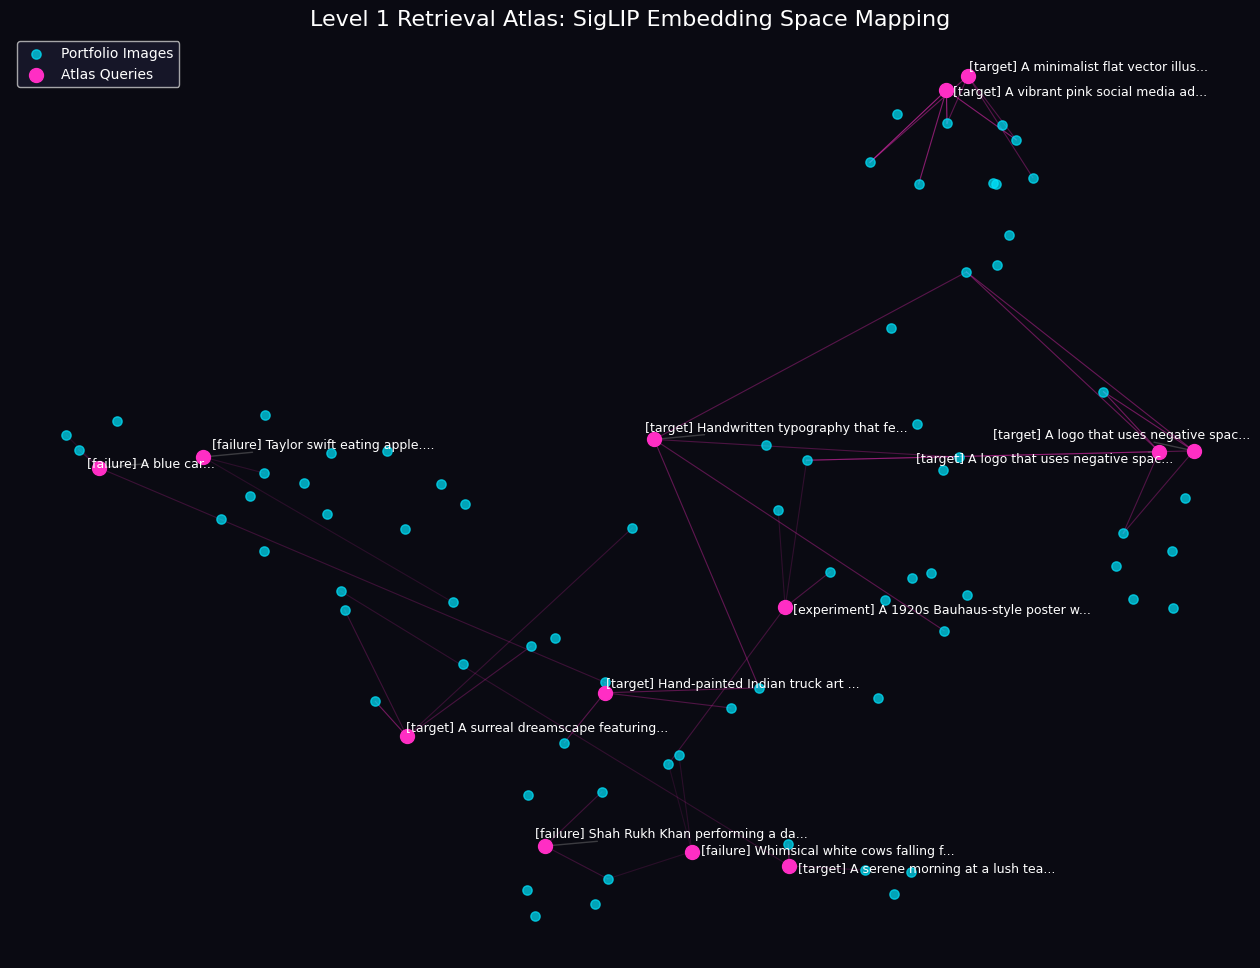

In [18]:
# Regenerate UMAP with the updated 15-prompt atlas
!pip install -q adjustText

import numpy as np
import torch
import umap
from adjustText import adjust_text
import matplotlib.pyplot as plt
import os

# Ensure we use the latest embeddings and paths
image_embeds_np = embeddings_tensor.cpu().numpy()
n_images = len(valid_paths)

# Sync with the updated atlas_queries from the previous cell
query_texts = [q for q, _ in atlas_queries]
text_embeds = []

print(f"Generating embeddings for {len(query_texts)} atlas queries...")
with torch.no_grad():
    for q in query_texts:
        inputs = processor(text=[q], return_tensors="pt", padding="max_length")
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        t_out = model.text_model(**inputs)
        t_emb = t_out.pooler_output
        t_emb = t_emb / t_emb.norm(dim=-1, keepdim=True)
        text_embeds.append(t_emb.cpu().numpy())

text_embeds_np = np.vstack(text_embeds)

# Modality-gap correction (mean-centering)
image_embeds_centered = image_embeds_np - image_embeds_np.mean(axis=0, keepdims=True)
text_embeds_centered  = text_embeds_np  - text_embeds_np.mean(axis=0, keepdims=True)
combined = np.vstack([image_embeds_centered, text_embeds_centered])

# UMAP reduction
reducer = umap.UMAP(n_components=2, n_neighbors=8, min_dist=0.15, metric="cosine", random_state=42)
embedding_2d = reducer.fit_transform(combined)
img_2d = embedding_2d[:n_images]
text_2d = embedding_2d[n_images:]

# Create edges for the 'atlas' connections
edges = []
for qi, (query, _) in enumerate(atlas_queries):
    hits = atlas_results.get(query, [])
    for img, label in hits:
        fname = label.split("  (sim:")[0].strip()
        try:
            score_str = label.split("sim: ")[1].replace(")", "").strip()
            score = float(score_str)
        except:
            score = 1.0
        match_idx = next((i for i, p in enumerate(valid_paths) if os.path.basename(p) == fname), None)
        if match_idx is not None:
            edges.append((qi, match_idx, score))

# Plotting
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(figsize=(16, 12), facecolor="#0a0a12")
ax.set_facecolor("#0a0a12")

# Draw neon connections
if edges:
    max_score = max(e[2] for e in edges)
    for qi, ii, score in edges:
        alpha = 0.1 + 0.5 * (score / max_score)
        ax.plot([text_2d[qi, 0], img_2d[ii, 0]], [text_2d[qi, 1], img_2d[ii, 1]],
                color="#ff2ec4", alpha=alpha, linewidth=0.8, zorder=1)

# Plot points
ax.scatter(img_2d[:, 0], img_2d[:, 1], s=45, color="#00e5ff", alpha=0.7, label="Portfolio Images", zorder=2)
ax.scatter(text_2d[:, 0], text_2d[:, 1], s=100, color="#ff2ec4", alpha=1.0, label="Atlas Queries", zorder=3)

# Add labels with adjustText
texts = []
for i, (query, category) in enumerate(atlas_queries):
    short_label = f"[{category.split(':')[0]}] {query[:30]}..."
    texts.append(ax.text(text_2d[i, 0], text_2d[i, 1], short_label, color="white", fontsize=9))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="->", color="#888888", alpha=0.4))

plt.title("Level 1 Retrieval Atlas: SigLIP Embedding Space Mapping", color="white", fontsize=16)
plt.legend(facecolor="#1a1a2e", labelcolor="white")
plt.axis("off")
plt.show()